In [27]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [28]:
rng = np.random.default_rng(7)
n_base = 1500
x = rng.uniform(-10 , 20 , size = n_base)
beta0_true , beta1_true = 5.0 , 2.5
y_true = beta0_true + beta1_true * x
sigma = 0.8 + 0.35 * (x + 10)
eps = rng.normal(0.0 , sigma , size = n_base)
y = y_true + eps
k = 120
x_cl = rng.uniform(18.5 , 20.0 , size = k)
y_true_cl = beta0_true + beta1_true * x_cl
sigma_cl = 20.0
y_cl = y_true_cl + rng.normal(0.0 , sigma_cl , size = k)
X = np.concatenate([x , x_cl])
Y = np.concatenate([y , y_cl])

In [29]:
sigma_all = np.concatenate([sigma , np.full(k , sigma_cl)])
w = 1.0 / (sigma_all ** 2)
X_design = sm.add_constant(X)
ols = sm.OLS(Y , X_design).fit()
wls = sm.WLS(Y , X_design , weights = w).fit()
b0_ols , b1_ols = ols.params
b0_wls , b1_wls = wls.params
xg = np.linspace(X.min() , X.max() , 400)
Xg = sm.add_constant(xg)
yhat_ols = ols.predict(Xg)
yhat_wls = wls.predict(Xg)
yline_true = beta0_true + beta1_true * xg
res_ols = Y - ols.predict(X_design)
res_wls = Y - wls.predict(X_design)

In [30]:
def rmse(a , b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

def weighted_rmse(y , yhat , weights):
    return float(np.sqrt(np.sum(weights * (y - yhat) ** 2) / np.sum(weights)))

def binned_std(x , r , bins = 30):
    edges = np.linspace(x.min() , x.max() , bins + 1)
    mids = 0.5 * (edges[ : -1] + edges[1 : ])
    stds = np.full(bins , np.nan)
    for i in range(bins):
        m = (x >= edges[i]) & (x < edges[i + 1])
        if np.sum(m) >= 15:
            stds[i] = np.std(r[m] , ddof = 1)
    return mids , stds

In [31]:
rmse_all_ols = rmse(Y , ols.predict(X_design))
rmse_all_wls = rmse(Y , wls.predict(X_design))
clean_mask = X <= 17.0
rmse_clean_ols = rmse(Y[clean_mask] , ols.predict(X_design)[clean_mask])
rmse_clean_wls = rmse(Y[clean_mask] , wls.predict(X_design)[clean_mask])
wrmse_ols = weighted_rmse(Y , ols.predict(X_design) , w)
wrmse_wls = weighted_rmse(Y , wls.predict(X_design) , w)
mid , std_ols = binned_std(X , res_ols , bins = 30)
_ , std_wls = binned_std(X , res_wls , bins = 30)
plt.rcParams.update({
    "figure.dpi": 160 , "axes.grid": True , "grid.alpha": 0.22 ,
    "axes.titlesize": 14 , "axes.labelsize": 11 , "legend.framealpha": 0.95 ,
})
cluster_mask = X >= 18.5

Text(0.5, 1.0, 'Same Data, Different Trust: OLS Can Get Pulled by High-Variance Points')

Text(0.5, 0, 'X')

Text(0, 0.5, 'y')

Text(0.02, 0.98, 'True slope: 2.50\nOLS slope: 2.55\nWLS slope: 2.50\n\nRMSE (all): OLS 8.28 | WLS 8.30\nRMSE (clean): OLS 6.09 | WLS 6.07')

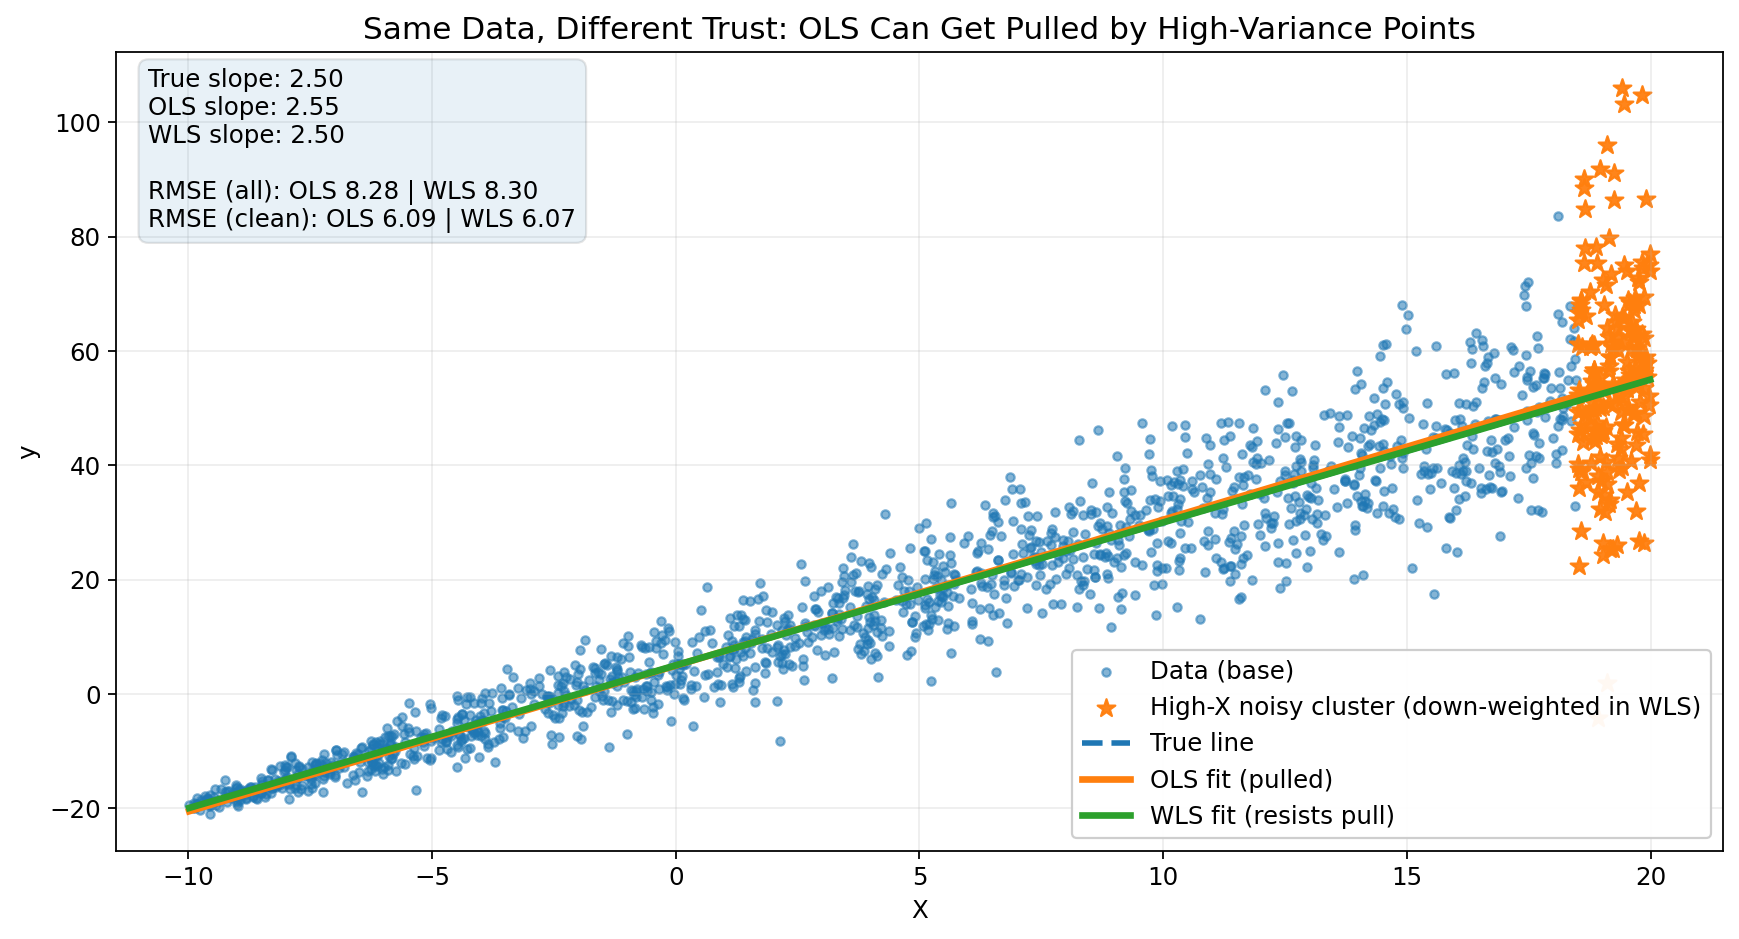

In [32]:
fig = plt.figure(figsize = (11 , 6))
ax = plt.gca()
ax.scatter(X[ ~ cluster_mask] , Y[ ~ cluster_mask] , s = 14 , alpha = 0.55 , label = "Data (base)")
ax.scatter(X[cluster_mask] , Y[cluster_mask] , s = 70 , marker = "*" , alpha = 0.95 ,
           label = "High-X noisy cluster (down-weighted in WLS)")
ax.plot(xg , yline_true , linewidth = 2.5 , linestyle = "--" , label = "True line")
ax.plot(xg , yhat_ols , linewidth = 3.0 , label = "OLS fit (pulled)")
ax.plot(xg , yhat_wls , linewidth = 3.0 , label = "WLS fit (resists pull)")
ax.set_title("Same Data, Different Trust: OLS Can Get Pulled by High-Variance Points")
ax.set_xlabel("X")
ax.set_ylabel("y")
txt = (
    f"True slope: {beta1_true:.2f}\n"
    f"OLS slope: {b1_ols:.2f}\n"
    f"WLS slope: {b1_wls:.2f}\n\n"
    f"RMSE (all): OLS {rmse_all_ols:.2f} | WLS {rmse_all_wls:.2f}\n"
    f"RMSE (clean): OLS {rmse_clean_ols:.2f} | WLS {rmse_clean_wls:.2f}"
)
ax.text(0.02 , 0.98 , txt , transform = ax.transAxes , va = "top" , ha = "left" ,
        bbox = dict(boxstyle = "round , pad = 0.4" , alpha = 0.10))
ax.legend(loc = "lower right")
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Residuals: "Spread grows with X" (Heteroskedasticity)')

Text(0.5, 0, 'X')

Text(0, 0.5, 'Residual')

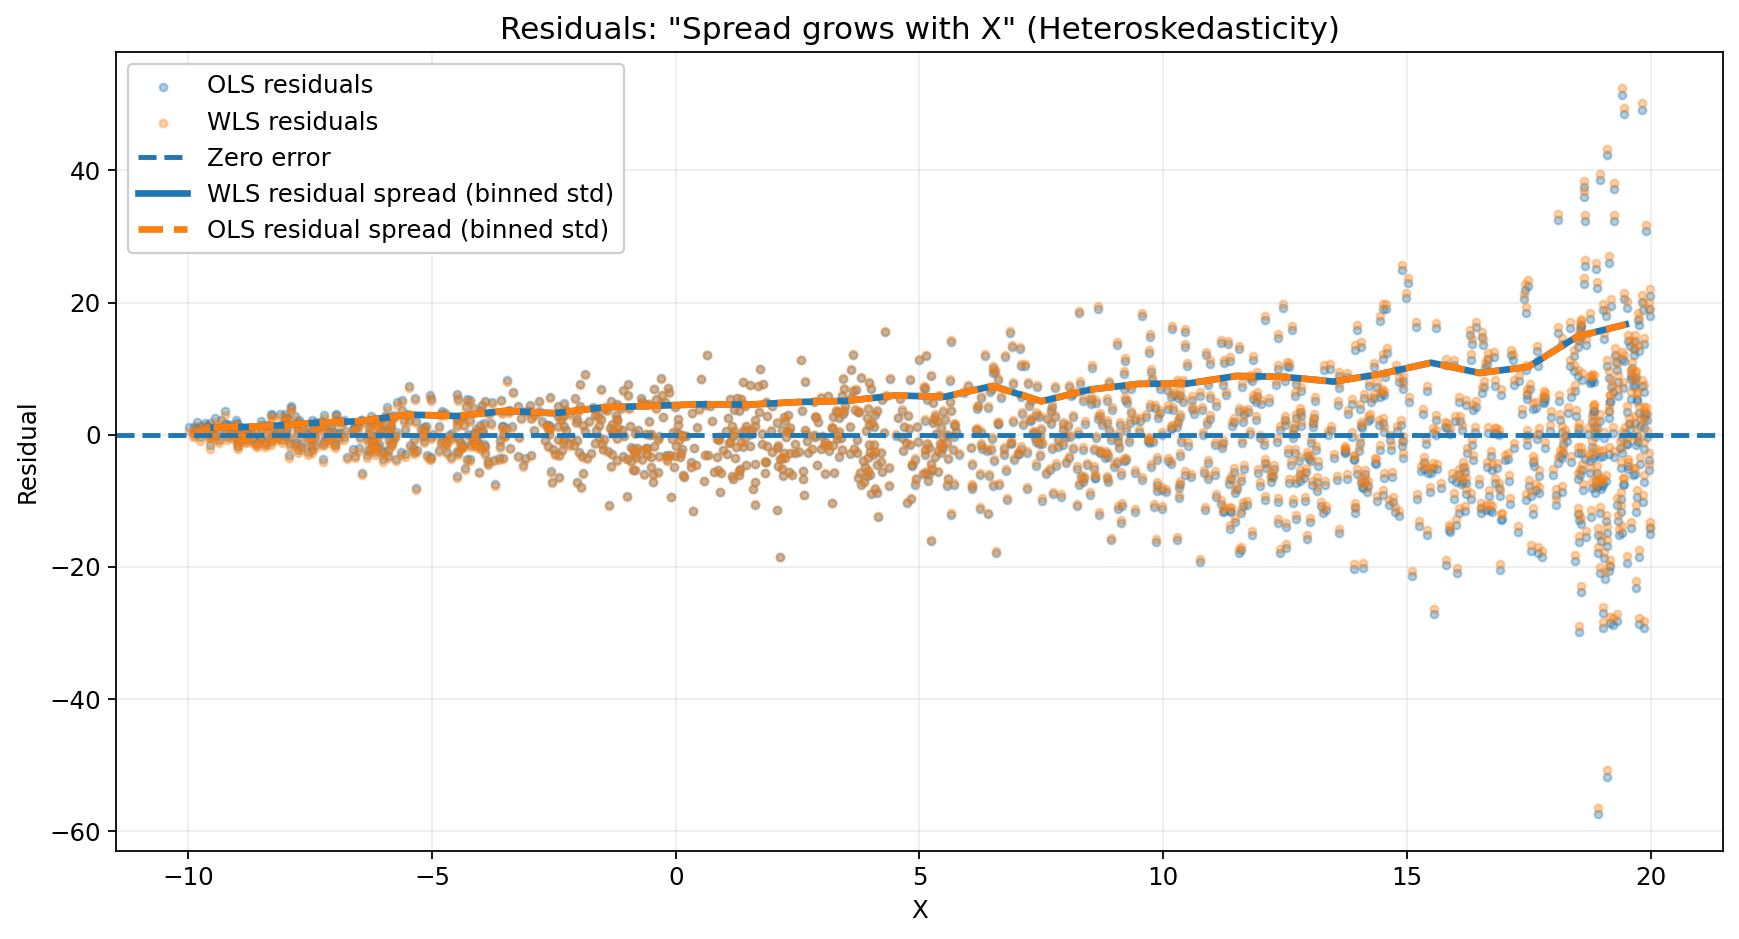

In [33]:
fig = plt.figure(figsize = (11 , 6))
ax = plt.gca()
ax.scatter(X , res_ols , s = 12 , alpha = 0.35 , label = "OLS residuals")
ax.scatter(X , res_wls , s = 12 , alpha = 0.35 , label = "WLS residuals")
ax.axhline(0 , linewidth = 2.2 , linestyle = "--" , label = "Zero error")
ax.plot(mid , std_wls , linewidth = 3.0 , label = "WLS residual spread (binned std)" , zorder = 5)
ax.plot(mid , std_ols , linewidth = 3.0 , linestyle = "--" ,
        label = "OLS residual spread (binned std)" , zorder = 6)
ax.set_title('Residuals: "Spread grows with X" (Heteroskedasticity)')
ax.set_xlabel("X")
ax.set_ylabel("Residual")
ax.legend(loc = "upper left")
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'What WLS Does Under the Hood: Higher Variance → Lower Weight')

Text(0.5, 0, 'X')

Text(0, 0.5, 'Relative weight (higher = more trusted)')

Text(0.02, 0.98, 'WLS idea:\nGive less influence\nto high-variance points.')

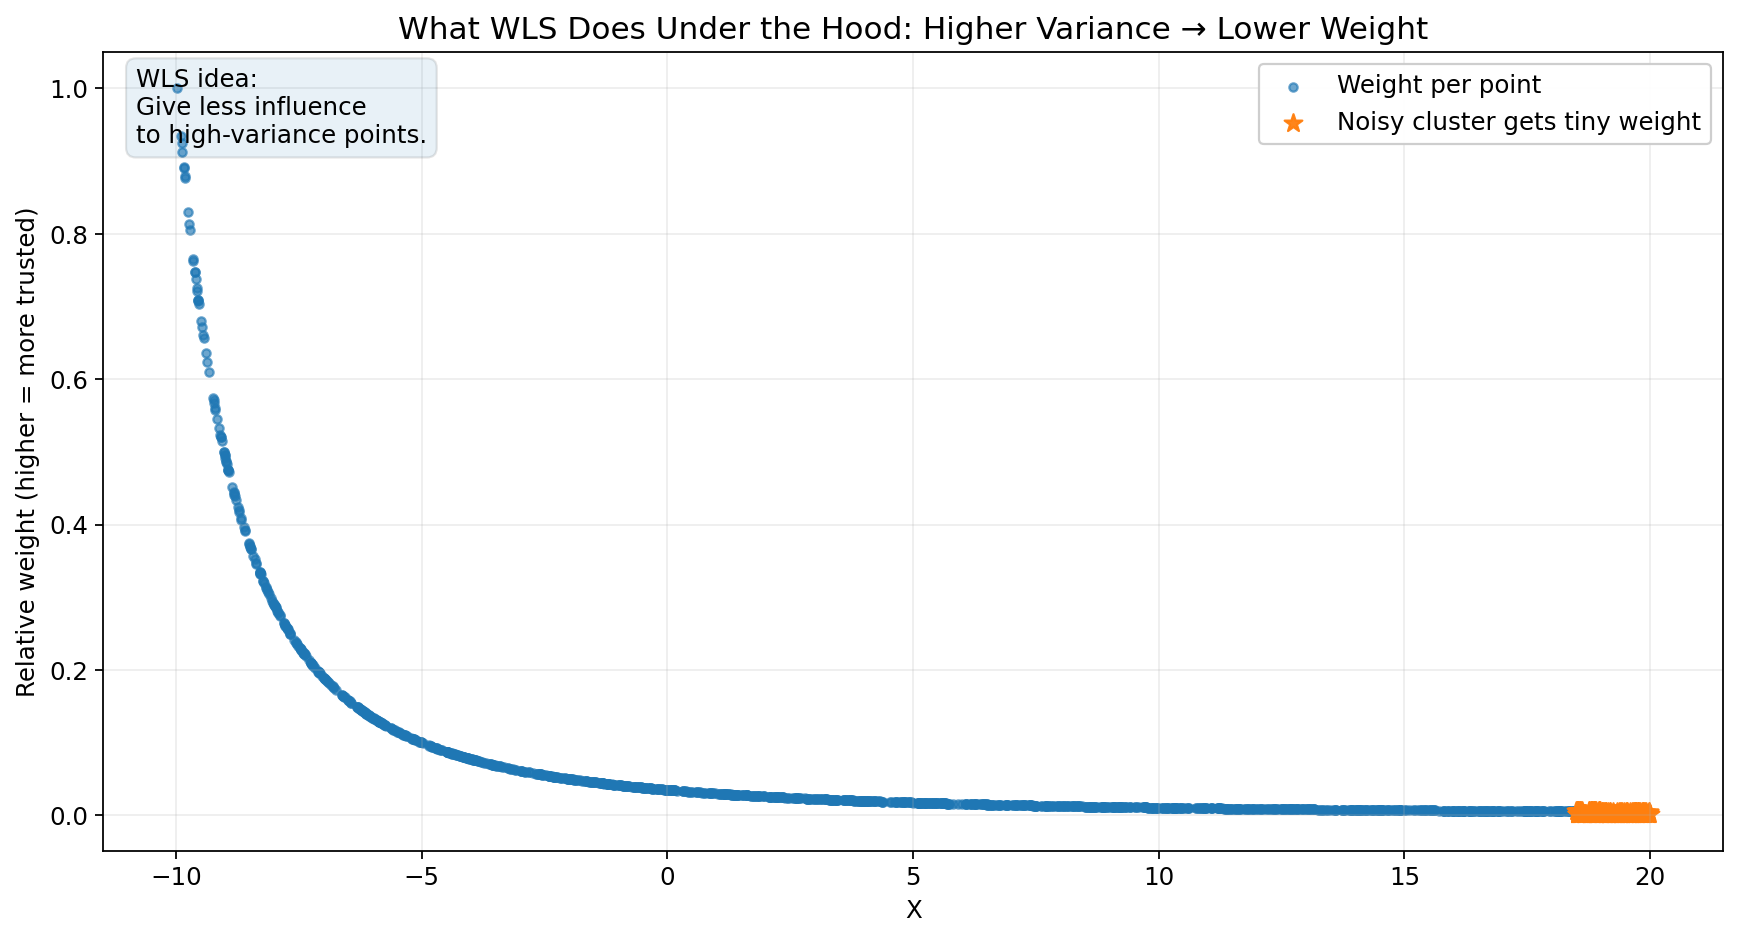

In [34]:
fig = plt.figure(figsize = (11 , 6))
ax = plt.gca()
w_rel = w / np.max(w)
ax.scatter(X[ ~ cluster_mask] , w_rel[ ~ cluster_mask] , s = 14 , alpha = 0.65 , label = "Weight per point")
ax.scatter(X[cluster_mask] ,  w_rel[cluster_mask] , s = 70 , marker = "*" , alpha = 0.95 ,
           label = "Noisy cluster gets tiny weight")
ax.set_title("What WLS Does Under the Hood: Higher Variance → Lower Weight")
ax.set_xlabel("X")
ax.set_ylabel("Relative weight (higher = more trusted)")
ax.text(0.02 , 0.98 ,
        "WLS idea:\nGive less influence\nto high-variance points." ,
        transform = ax.transAxes , va = "top" , ha = "left" ,
        bbox = dict(boxstyle = "round , pad = 0.4" , alpha = 0.10))
ax.legend(loc = "upper right")
plt.tight_layout()
plt.show()

In [35]:
print("========= Model Comparison =========")
print(f"True: slope = {beta1_true:.3f} | intercept = {beta0_true:.3f}")
print(f"OLS : slope = {b1_ols:.3f} | intercept = {b0_ols:.3f}")
print(f"WLS : slope = {b1_wls:.3f} | intercept = {b0_wls:.3f}")
print()
print(f"RMSE (all)   : OLS = {rmse_all_ols:.3f} | WLS = {rmse_all_wls:.3f}")
print(f"RMSE (clean) : OLS = {rmse_clean_ols:.3f} | WLS = {rmse_clean_wls:.3f}")
print(f"Weighted RMSE: OLS = {wrmse_ols:.3f} | WLS = {wrmse_wls:.3f}")

========= Model Comparison =========
True: slope = 2.500 | intercept = 5.000
OLS : slope = 2.552 | intercept = 4.976
WLS : slope = 2.500 | intercept = 5.030

RMSE (all)   : OLS = 8.282 | WLS = 8.300
RMSE (clean) : OLS = 6.091 | WLS = 6.068
Weighted RMSE: OLS = 3.194 | WLS = 3.161
